<a href="https://colab.research.google.com/github/keeratkaurbhatia/The-Open-Source-Horcrux/blob/main/E11/OST_Exp11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data from Mendeley...
Successfully loaded 10 papers!


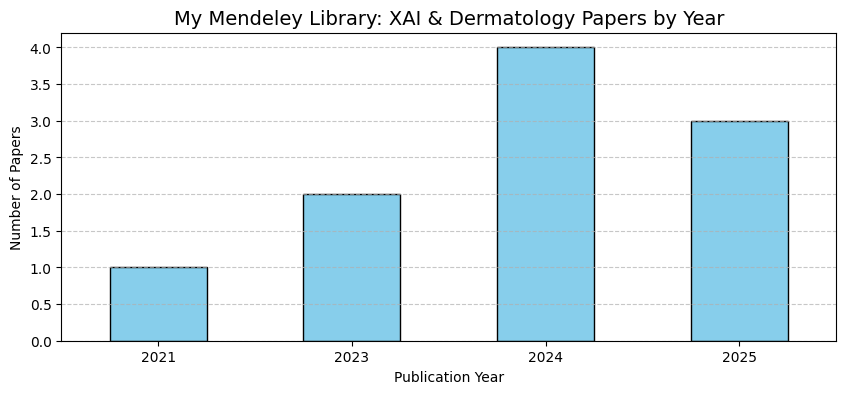

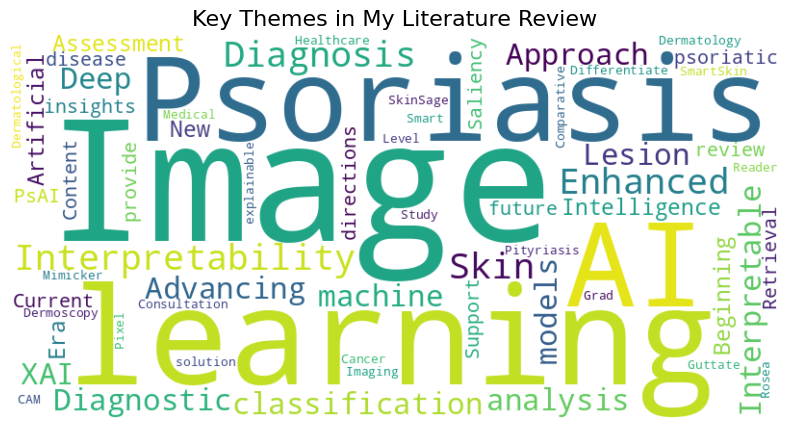

In [6]:
# 1. INSTALL DEPENDENCIES
!pip install pybtex wordcloud matplotlib pandas -q

from pybtex.database import parse_file
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

# 2. LOAD DATA FROM MENDELEY EXPORT
print("Loading data from Mendeley...")
try:

    bib_data = parse_file('mendeley_data.bib')

    extracted_data = []
    for key, entry in bib_data.entries.items():
        title = entry.fields.get('title', 'Unknown').replace('{', '').replace('}', '')
        year = entry.fields.get('year', '0')
        extracted_data.append({"Year": int(year), "Title": title})

    df = pd.DataFrame(extracted_data)
    print(f"Successfully loaded {len(df)} papers!")

    # 3. ANALYSIS 1: Publications over time
    plt.figure(figsize=(10, 4))
    # Filter out any '0' years if a paper was missing a date
    df_filtered = df[df['Year'] > 1900]
    df_filtered['Year'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('My Mendeley Library: XAI & Dermatology Papers by Year', fontsize=14)
    plt.xlabel('Publication Year')
    plt.ylabel('Number of Papers')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 4. ANALYSIS 2: Word Cloud
    text = " ".join(df['Title'].tolist())
    text = re.sub(r'\b(in|of|for|and|to|A|An|The|on|with|based)\b', '', text, flags=re.IGNORECASE)

    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Key Themes in My Literature Review', fontsize=16)
    plt.show()

except FileNotFoundError:
    print(" ERROR: Could not find 'mendeley_data.bib'.")

/tmp/ipykernel_12195/514918625.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bigrams.values, y=top_bigrams.index, palette='magma')


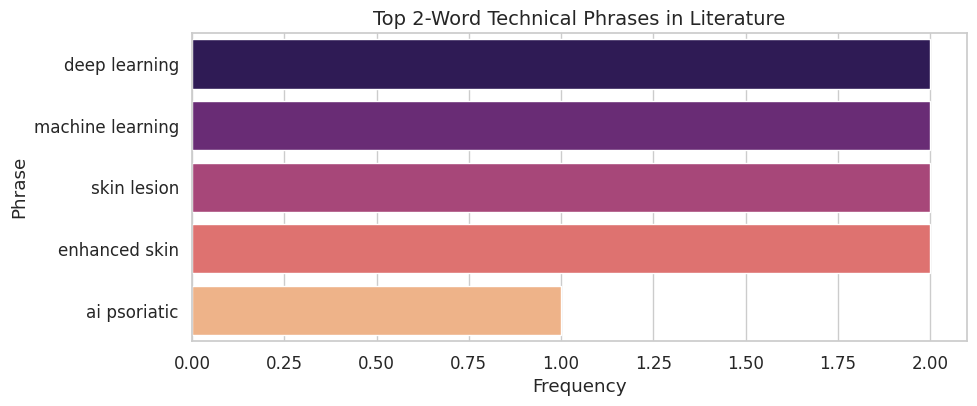

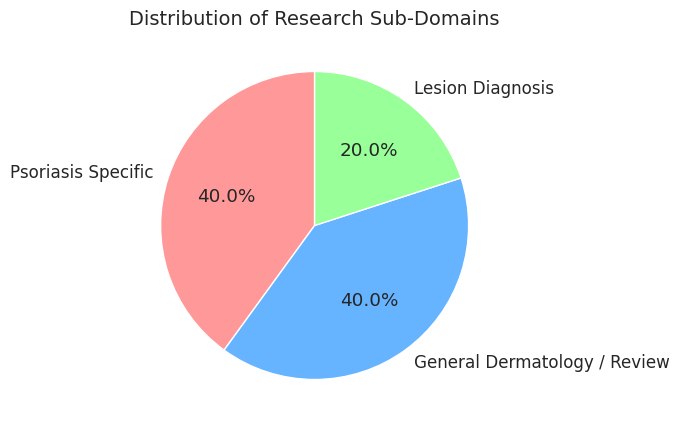


 NLP pipeline complete!


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

# Use the 'df' from the previous cell
titles = df['Title'].tolist()


# ANALYSIS 3: Bigram Extraction

# Looks for the most common 2-word combinations
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
X = vectorizer.fit_transform(titles)

# Create a DataFrame of the phrases and their frequencies
bigram_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
top_bigrams = bigram_df.sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_bigrams.values, y=top_bigrams.index, palette='magma')
plt.title('Top 2-Word Technical Phrases in Literature', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Phrase')
plt.show()



# ANALYSIS 4: Domain Clustering (Categorizing the Papers)

def categorize_paper(title):
    title_lower = title.lower()
    if 'psoriasis' in title_lower or 'psai' in title_lower:
        return 'Psoriasis Specific'
    elif 'lesion' in title_lower:
        return 'Lesion Diagnosis'
    else:
        return 'General Dermatology / Review'

df['Category'] = df['Title'].apply(categorize_paper)

# Plot the distribution
plt.figure(figsize=(8, 5))
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Research Sub-Domains', fontsize=14)
plt.ylabel('') # Hides the y-label
plt.show()

print("\n NLP pipeline complete!")